In [1]:
import rioxarray as rio
import matplotlib.pyplot as plt
import numpy as np
import skimage

In [2]:
Band2_before = rio.open_rasterio(r"C:\Users\liamt\Downloads\Before Tornado\S2B_MSIL1C_20251107T133139_N0511_R081_T22JCS_20251107T150445.SAFE\GRANULE\L1C_T22JCS_A045295_20251107T133140\IMG_DATA\T22JCS_20251107T133139_B02.jp2")
Band4_before = rio.open_rasterio(r"C:\Users\liamt\Downloads\Before Tornado\S2B_MSIL1C_20251107T133139_N0511_R081_T22JCS_20251107T150445.SAFE\GRANULE\L1C_T22JCS_A045295_20251107T133140\IMG_DATA\T22JCS_20251107T133139_B04.jp2")
Band8_before = rio.open_rasterio(r"C:\Users\liamt\Downloads\Before Tornado\S2B_MSIL1C_20251107T133139_N0511_R081_T22JCS_20251107T150445.SAFE\GRANULE\L1C_T22JCS_A045295_20251107T133140\IMG_DATA\T22JCS_20251107T133139_B08.jp2")

In [3]:
Band2 = rio.open_rasterio(r"C:\Users\liamt\Downloads\After Tornado\S2B_MSIL1C_20251110T133829_N0511_R124_T22JCS_20251110T165351.SAFE\GRANULE\L1C_T22JCS_A045338_20251110T133912\IMG_DATA\T22JCS_20251110T133829_B02.jp2")
Band3 = rio.open_rasterio(r"C:\Users\liamt\Downloads\After Tornado\S2B_MSIL1C_20251110T133829_N0511_R124_T22JCS_20251110T165351.SAFE\GRANULE\L1C_T22JCS_A045338_20251110T133912\IMG_DATA\T22JCS_20251110T133829_B03.jp2")
Band4 = rio.open_rasterio(r"C:\Users\liamt\Downloads\After Tornado\S2B_MSIL1C_20251110T133829_N0511_R124_T22JCS_20251110T165351.SAFE\GRANULE\L1C_T22JCS_A045338_20251110T133912\IMG_DATA\T22JCS_20251110T133829_B04.jp2")
Band8 = rio.open_rasterio(r"C:\Users\liamt\Downloads\After Tornado\S2B_MSIL1C_20251110T133829_N0511_R124_T22JCS_20251110T165351.SAFE\GRANULE\L1C_T22JCS_A045338_20251110T133912\IMG_DATA\T22JCS_20251110T133829_B08.jp2")

In [4]:
red_in = (Band8/Band4)*0.1
green_in = (Band8_before/Band4_before)*0.09
blue_in = Band2/Band2.max()

In [5]:
red_in = red_in.rio.reproject("EPSG:4326")
green_in = green_in.rio.reproject("EPSG:4326")
blue_in = blue_in.rio.reproject("EPSG:4326")

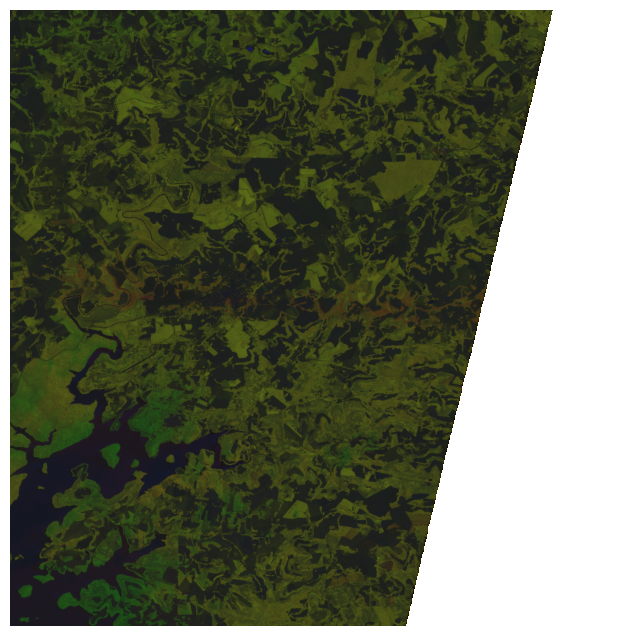

In [6]:
lat_min, lat_max = -25.4, -25.6
lon_min, lon_max = -52.6, -52.4

green = red_in.sel(y=slice(lat_min, lat_max), x=slice(lon_min, lon_max)).squeeze()
red = green_in.sel(y=slice(lat_min, lat_max), x=slice(lon_min, lon_max)).squeeze()
blue = blue_in.sel(y=slice(lat_min, lat_max), x=slice(lon_min, lon_max)).squeeze()
rgb = np.dstack((red, green, blue))

#Normalize for display (important!)
rgb_min = 0
rgb_max = 5_000
rgb_scaled = np.clip((rgb - rgb_min) / (rgb_max - rgb_min), 0, 1)

plt.figure(figsize=(8, 8))
plt.imshow(rgb)
plt.axis("off")
plt.show()

Text(0.5, 1.0, 'Candidate tornado pixels')

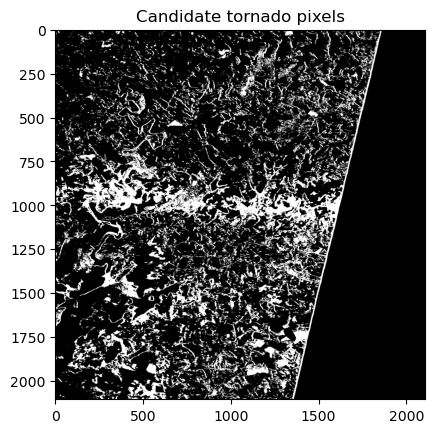

In [7]:
from skimage.morphology import  dilation, footprint_rectangle
# Example: detect red-dominant pixels
#mask = (rgb_scaled[:, :, 0] > rgb_scaled[:, :, 1]) & \
       #(rgb_scaled[:, :, 0] > rgb_scaled[:, :, 2])

#test 1 adjusting rgb_scaled values using a threshold, kinda works 95% and higher but makes clutter south of town bigger
threshold = 0.97 # n% of the max between green/blue
mask = (rgb_scaled[:, :, 0] > threshold * rgb_scaled[:, :, 1]) & \
       (rgb_scaled[:, :, 0] > threshold * rgb_scaled[:, :, 2])

#test 2 using dilation to increase pixels size
footprint = footprint_rectangle((1, 6)) #square sets a rectangle to include neighbors in a 3 by 5 area can increase size (Height, Width)
mask_dilated = dilation(mask, footprint) 
#test 3 both?

plt.imshow(mask_dilated, cmap="gray")
plt.title("Candidate tornado pixels")

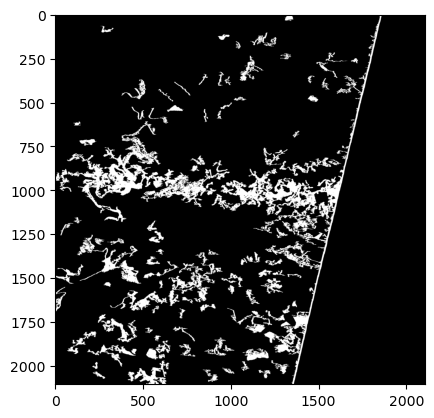

In [50]:
from skimage.morphology import remove_small_objects
clean_mask = remove_small_objects(mask_dilated, max_size = 500)

plt.imshow(clean_mask, cmap = "gray")

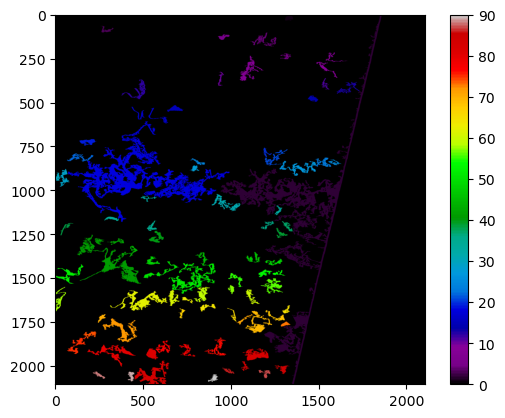

In [43]:
from skimage.measure import label, regionprops
labeled_mask = label(clean_mask, connectivity = 2)
regions = regionprops(labeled_mask)
plt.imshow(labeled_mask, cmap = 'nipy_spectral')  
plt.colorbar()
plt.show()

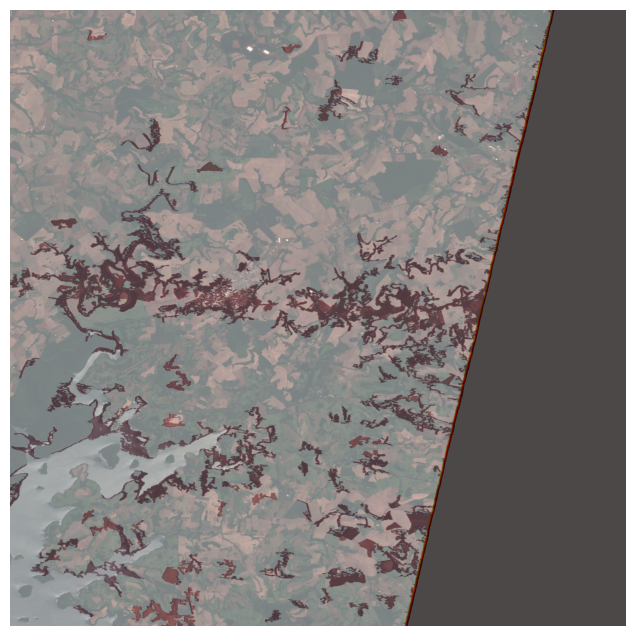

In [42]:
from skimage import measure

lat_min, lat_max = -25.4, -25.6
lon_min, lon_max = -52.6, -52.4

red2 = Band4.rio.reproject("EPSG:4326")
green2 = Band3.rio.reproject("EPSG:4326")
blue2 = Band2.rio.reproject("EPSG:4326")

red = red2.sel(y=slice(lat_min, lat_max), x=slice(lon_min, lon_max)).squeeze()
green = green2.sel(y=slice(lat_min, lat_max), x=slice(lon_min, lon_max)).squeeze()
blue = blue2.sel(y=slice(lat_min, lat_max), x=slice(lon_min, lon_max)).squeeze()
rgb = np.dstack([red, green, blue])

rgb_min = 0
rgb_max = 5_000
rgb_scaled = np.clip((rgb - rgb_min) / (rgb_max - rgb_min), 0, 1)

plt.figure(figsize=(8, 8))
plt.imshow(rgb_scaled)
plt.imshow(clean_mask, cmap = "Reds", alpha = 0.3)

plt.axis("off")
plt.show()